6.	Calculate a video's local binary pattern of the top five entropy frames. (use Cooking.avi). Show the Fourier transform of the results. Show the histograms.

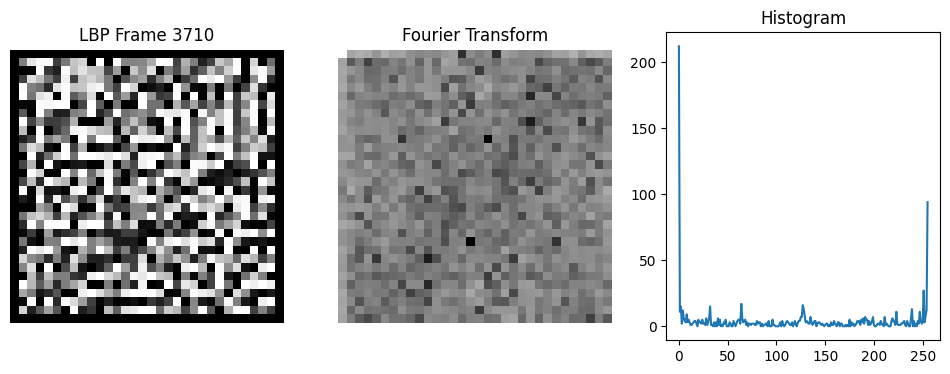

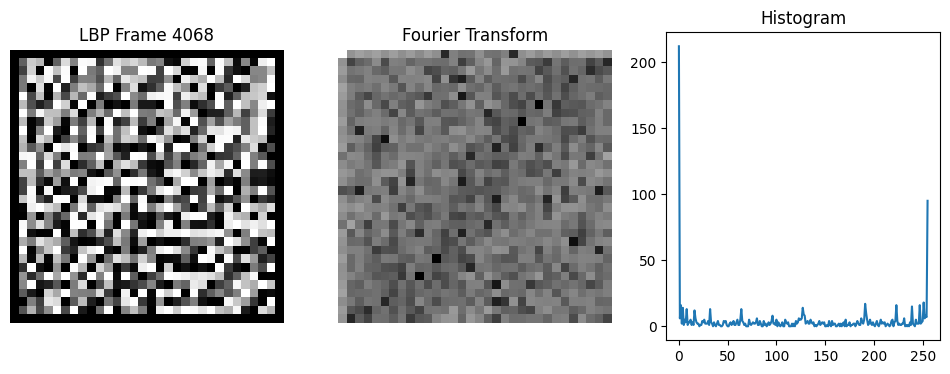

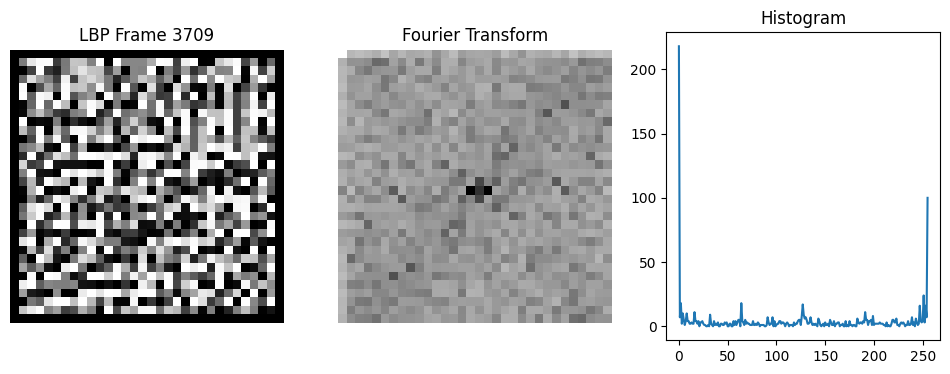

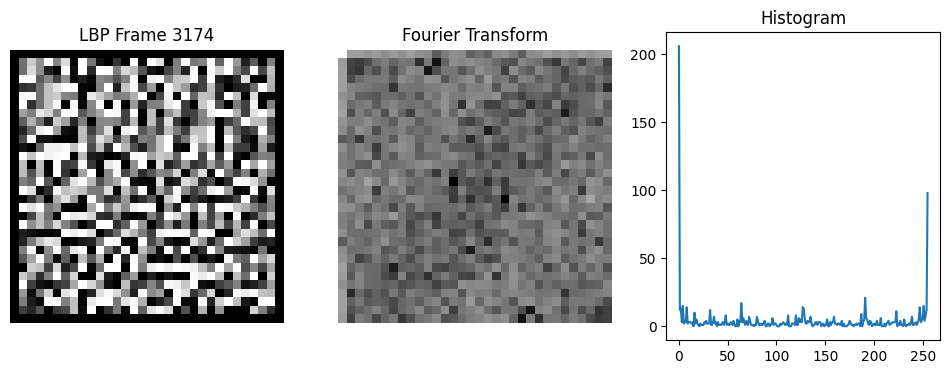

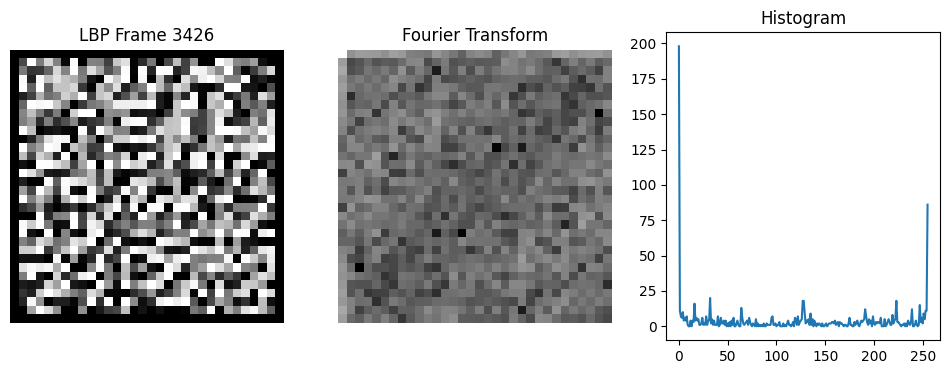

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

def lbp(img):

    rows, cols = img.shape

    output = np.zeros((rows, cols), dtype=np.uint8)

    for i in range(1, rows-1):

        for j in range(1, cols-1):

            center = img[i][j]

            binary = ""

            # 8 neighbors
            positions = [
                (i-1,j-1),
                (i-1,j),
                (i-1,j+1),
                (i,j+1),
                (i+1,j+1),
                (i+1,j),
                (i+1,j-1),
                (i,j-1)
            ]

            for x,y in positions:

                if img[x][y] >= center:
                    binary += "1"
                else:
                    binary += "0"

            output[i][j] = int(binary,2)

    return output



def entropy(img):

    hist = [0]*256

    rows, cols = img.shape
    total = rows * cols

    for i in range(rows):
        for j in range(cols):
            hist[img[i][j]] += 1

    ent = 0

    for h in hist:

        if h != 0:

            p = h / total

            ent -= p * math.log2(p)

    return ent

def manual_dft(img):

    rows, cols = img.shape

    real = np.zeros((rows,cols))
    imag = np.zeros((rows,cols))
    magnitude = np.zeros((rows,cols))

    for u in range(rows):

        for v in range(cols):

            sum_real = 0
            sum_imag = 0

            for x in range(rows):

                for y in range(cols):

                    angle = 2 * math.pi * (
                        (u*x/rows) + (v*y/cols)
                    )

                    pixel = img[x][y]

                    sum_real += pixel * math.cos(angle)
                    sum_imag -= pixel * math.sin(angle)

            real[u][v] = sum_real
            imag[u][v] = sum_imag

            magnitude[u][v] = math.sqrt(
                sum_real**2 + sum_imag**2
            )

    magnitude = np.log(1 + magnitude)

    return magnitude

cap = cv2.VideoCapture("E:\\BG\\vid.mp4")

frames = []
entropies = []

count = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    
    gray = cv2.resize(gray,(32,32))

    e = entropy(gray)

    frames.append(gray)
    entropies.append((e,count))

    count += 1

cap.release()

entropies.sort(reverse=True)

top5 = entropies[:5]


for idx, (e, frame_no) in enumerate(top5):

    img = frames[frame_no]

    # LBP
    lbp_img = lbp(img)

    # Fourier Transform
    fourier = manual_dft(lbp_img)

    # Histogram
    hist = [0]*256

    rows, cols = lbp_img.shape

    for i in range(rows):
        for j in range(cols):
            hist[lbp_img[i][j]] += 1


    plt.figure(figsize=(12,4))

    # Original
    plt.subplot(1,3,1)
    plt.imshow(lbp_img,cmap='gray')
    plt.title(f"LBP Frame {frame_no}")
    plt.axis("off")

    # Fourier
    plt.subplot(1,3,2)
    plt.imshow(fourier,cmap='gray')
    plt.title("Fourier Transform")
    plt.axis("off")

    # Histogram
    plt.subplot(1,3,3)
    plt.plot(hist)
    plt.title("Histogram")

    plt.show()